# Regresores logísticos - Modelos lineales de clasificación

Vamos a trabajar con el dataset conocido como *Wisconsin Diagnostic Breast Cancer Database* (WDBC), que es un conjunto de datos muy utilizado en el aprendizaje automático y la bioinformática para el diagnóstico de cáncer de mama.  Contiene información sobre biopsias de mama y se usa comúnmente para entrenar modelos de clasificación que puedan distinguir entre tumores benignos y malignos.

Este dataset fue creado por el Dr. William H. Wolberg, el Dr. W. Nick Street y colaboradores, y está disponible públicamente en el repositorio de *Machine Learning* de la Universidad de California en Irvine (UCI).

**Contenido del Dataset:**

El WDBC contiene 569 instancias (observaciones) de biopsias de mama.  Cada instancia está descrita por 32 atributos:

* **ID number:** Identificador único de la muestra (no relevante para el análisis).
* **Diagnosis:**  La variable objetivo o clase. Indica si el tumor es maligno (M) o benigno (B).  Este es el valor que queremos predecir.
* **30 características numéricas reales:**  Estas son las medidas obtenidas a partir de las imágenes digitalizadas de las biopsias.  Se calculan 10 características para cada una de las tres dimensiones (radio, textura y perímetro) de la imagen de la masa celular:
    * **Radio:**  Promedio del radio de la masa.
    * **Textura:**  Desviación estándar de la escala de grises.
    * **Perímetro:**  Tamaño del contorno de la masa.
    * **Área:**  Área de la masa.
    * **Suavidad:**  Medida de la suavidad de la masa.
    * **Compacidad:**  Compacidad de la masa (derivada del perímetro y el área).
    * **Concavidad:**  Número de porciones cóncavas del contorno.
    * **Puntos cóncavos:**  Número de puntos extremos cóncavos del contorno.
    * **Simetría:**  Medida de la simetría de la masa.
    * **Dimensión fractal:**  "Costa" aproximada.

    Para cada una de estas 10 características, se proporcionan tres valores:
        * **Media:**  El valor promedio de la característica.
        * **Desviación Estándar:**  La variabilidad de la característica.
        * **Peor (o Máximo):**  El valor máximo de la característica.


In [1]:
from pathlib import Path

data_dir = Path().resolve().parent / "data" / "raw"
data_name = "breast-cancer-wisconsin.csv"
filepath = data_dir / data_name

In [2]:
import pandas as pd

df = pd.read_csv(filepath)        

df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [4]:
df = df.drop(['id', 'Unnamed: 32'], axis=1)

Vamos a crear un modelo de regresión logística para predecir la variable **diagnosis**, que es una variable binaria.

In [5]:
df['diagnosis'].value_counts()

diagnosis
B    357
M    212
Name: count, dtype: int64

In [6]:
from sklearn.model_selection import train_test_split

X = df.drop(['diagnosis'], axis=1)
y = df['diagnosis']

X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y,
    stratify=y,
    train_size=0.8,
    random_state=72, 
    )

print(f'Tamaño del conjunto de entrenamiento es: {X_train.shape}')
print(f'Tamaño del conjunto de prueba es: {X_test.shape}')

Tamaño del conjunto de entrenamiento es: (455, 30)
Tamaño del conjunto de prueba es: (114, 30)


Vamos a empezar con un modelo de regresión logística sin regularizar.

In [7]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=10000)
model.fit(X_train, y_train)
print(f'Train accuracy: {model.score(X_train, y_train):.3f}')
print(f'Test accuracy: {model.score(X_test, y_test):.3f}')

Train accuracy: 0.956
Test accuracy: 0.956


¿Qué significa este resultado?

# Métricas de evaluación

Para entender este resultado, veamos la matriz de confusión.

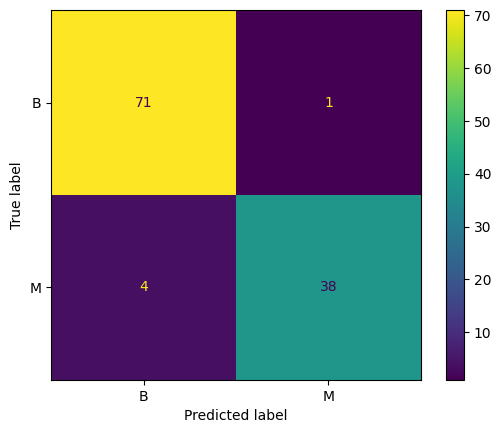

In [8]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(model, X_test, y_test);

El método score está entregando la exactitud (*accuracy*) del modelo, que es el porcentaje de aciertos del modelo, bien sea positivos o negativos.

La clase **classification report** nos entrega lel resumen de todas las métricas.

In [9]:
from sklearn.metrics import classification_report

print(classification_report(y_test, model.predict(X_test)));

              precision    recall  f1-score   support

           B       0.95      0.99      0.97        72
           M       0.97      0.90      0.94        42

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



Como este es un modelo lineal, podemos obtener los coeficientes asociados a cada característica:

In [10]:
coeficientes = pd.DataFrame(
    model.coef_.reshape(-1,1), 
    index=X_train.columns, 
    columns=['Coeficiente']
    )

coeficientes.loc['Intercepto'] = model.intercept_
coeficientes

,Coeficiente
radius_mean,-1.023578
texture_mean,-0.156093
perimeter_mean,0.140280
area_mean,-0.018076
smoothness_mean,0.134240
compactness_mean,0.177976
concavity_mean,0.441594
concave points_mean,0.225442
symmetry_mean,0.234834
fractal_dimension_mean,0.017015


# Ejercicio

Haga un modelo de regresión logística para predecir el nivel de ingreso usando el dataset disponible en http://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data.

Elimine las variables **native-country** y **education**.

Elimine los datos nulos.

Codifique las variables categóricas one-hot y estandarice las numéricas con StandardScaler.

Reporte el *accuracy* de entrenamiento y el de prueba.

Presente la matriz de confusión, el reporte de clasificación, y analice los resultados obtenidos. ¿El modelo está balanceado? ¿Con qué clase tiene mejor desempeño?

Reporte los coeficientes del modelo entrenado.